In [1]:
# Importações e Configuração Inicial

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

# Configurações visuais
sns.set(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 14

In [2]:
# Carregando a FatoWorkItens

arquivo = "TabelaFatoWorkItens.csv"

df = pd.read_csv(arquivo, sep=",", encoding="utf-8")

df.head()

,Area Path,Assigned To,Ano,Trimestre,Mês,Dia,Soma de DE x PARA conceito Effort (CES).NÍVEL DE DOR CES,DE x PARA conceito Effort (CES).QUAL É A TRAVANCA?,DE x PARA conceito Effort (CES).TIPO DE TRAVA,DE x PARA Op versus Épico.Solução,DE x PARA Op versus Épico.Tipo de Task,DE x PARA Sprint.para,ID&Status,Is Current,Iteration Path,State,Title,Contagem de Work Item Id,Work Item Type
0,AMBEV-ANALYTICS-DATA-CHAPTER-SALES\B2B Analyti...,Matheus de Oliveira Trindade,2024,Trim 4,outubro,31,2.0,Discovery MIX travado,Mapeamento,BI Farol TTV 3.0,Modelagem de dados,Q4.24 - S1,1710313_New,False,AMBEV-ANALYTICS-DATA-CHAPTER-SALES\Digital Ins...,New,Input Manual - DeParaSKU e MkupRedes,1,Action
1,AMBEV-ANALYTICS-DATA-CHAPTER-SALES\B2B Analyti...,Matheus de Oliveira Trindade,2024,Trim 4,novembro,30,2.0,Discovery MIX travado,Mapeamento,BI Farol TTV 3.0,Modelagem de dados,Q4.24 - S1,1710313_New,False,AMBEV-ANALYTICS-DATA-CHAPTER-SALES\Digital Ins...,New,Input Manual - DeParaSKU e MkupRedes,1,Action
2,AMBEV-ANALYTICS-DATA-CHAPTER-SALES\B2B Analyti...,Matheus de Oliveira Trindade,2024,Trim 4,dezembro,20,2.0,Discovery MIX travado,Mapeamento,BI Farol TTV 3.0,Modelagem de dados,Q4.24 - S1,1710313_New,True,AMBEV-ANALYTICS-DATA-CHAPTER-SALES\Digital Ins...,New,Input Manual - DeParaSKU e MkupRedes,1,Action
3,AMBEV-ANALYTICS-DATA-CHAPTER-SALES\B2B Analyti...,Adalton Neto,2024,Trim 4,outubro,31,NaN,NaN,NaN,Demanda Squad,Processos Squad,Q4.24 - S2,1717048_Waiting-Business-Review,False,AMBEV-ANALYTICS-DATA-CHAPTER-SALES\Digital Ins...,Waiting-Business-Review,Suporte PRICE INDEX,1,Technical Story
4,AMBEV-ANALYTICS-DATA-CHAPTER-SALES\B2B Analyti...,Adalton Neto,2024,Trim 4,outubro,31,NaN,NaN,NaN,Price Index,Ações para o produto,Q4.24 - S2,1717032_Developing,False,AMBEV-ANALYTICS-DATA-CHAPTER-SALES\Digital Ins...,Developing,Apresentação ao Stakeholder,1,Business Story


In [3]:
# Inspeção geral
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3617 entries, 0 to 3616
Data columns (total 19 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Area Path                                                 3617 non-null   str    
 1   Assigned To                                               3617 non-null   str    
 2   Ano                                                       3617 non-null   int64  
 3   Trimestre                                                 3617 non-null   str    
 4   Mês                                                       3617 non-null   str    
 5   Dia                                                       3617 non-null   int64  
 6   Soma de DE x PARA conceito Effort (CES).NÍVEL DE DOR CES  3350 non-null   float64
 7   DE x PARA conceito Effort (CES).QUAL É A TRAVANCA?        3350 non-null   str    
 8   DE x PARA conceito Effort (CE

In [6]:
# Colunas e índices
for i, col in enumerate(df.columns, start=1):
    print(i, "->", col)

1 -> Area Path
2 -> Assigned To
3 -> Ano
4 -> Trimestre
5 -> Mês
6 -> Dia
7 -> Soma de DE x PARA conceito Effort (CES).NÍVEL DE DOR CES
8 -> DE x PARA conceito Effort (CES).QUAL É A TRAVANCA?
9 -> DE x PARA conceito Effort (CES).TIPO DE TRAVA
10 -> DE x PARA Op versus Épico.Solução
11 -> DE x PARA Op versus Épico.Tipo de Task
12 -> DE x PARA Sprint.para
13 -> ID&Status
14 -> Is Current
15 -> Iteration Path
16 -> State
17 -> Title
18 -> Contagem de Work Item Id
19 -> Work Item Type


In [7]:
# Padronizando as colunas
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("ã", "a")
    .str.replace("á", "a")
    .str.replace("é", "e")
    .str.replace("í", "i")
    .str.replace("ó", "o")
    .str.replace("ú", "u")
    .str.replace("ç", "c")
    .str.replace(r"[^a-z0-9_]", "", regex=True)
)

df.columns

Index(['area_path', 'assigned_to', 'ano', 'trimestre', 'ms', 'dia',
       'soma_de_de_x_para_conceito_effort_cesnivel_de_dor_ces',
       'de_x_para_conceito_effort_cesqual_e_a_travanca',
       'de_x_para_conceito_effort_cestipo_de_trava',
       'de_x_para_op_versus_epicosolucao',
       'de_x_para_op_versus_epicotipo_de_task', 'de_x_para_sprintpara',
       'idstatus', 'is_current', 'iteration_path', 'state', 'title',
       'contagem_de_work_item_id', 'work_item_type'],
      dtype='str')

In [14]:
# Criando coluna de data a partir de Ano, Mes, Dia
df["data"] = pd.to_datetime(
    df[["ano", "ms", "dia"]].astype(str).agg("-".join, axis=1),
    errors="coerce"
)

df[["ano", "ms", "dia", "data"]].head()

C:\Users\jesse\AppData\Local\Temp\ipykernel_27296\577365395.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["data"] = pd.to_datetime(


,ano,ms,dia,data
0,2024,outubro,31,NaT
1,2024,novembro,30,NaT
2,2024,dezembro,20,NaT
3,2024,outubro,31,NaT
4,2024,outubro,31,NaT


In [15]:
df.isna().sum().sort_values(ascending=False)

data                                                     3617
de_x_para_sprintpara                                      321
de_x_para_conceito_effort_cesqual_e_a_travanca            267
de_x_para_conceito_effort_cestipo_de_trava                267
soma_de_de_x_para_conceito_effort_cesnivel_de_dor_ces     267
de_x_para_op_versus_epicosolucao                           14
de_x_para_op_versus_epicotipo_de_task                      14
area_path                                                   0
trimestre                                                   0
ano                                                         0
assigned_to                                                 0
ms                                                          0
dia                                                         0
idstatus                                                    0
iteration_path                                              0
is_current                                                  0
state   

In [16]:
col1 = df.columns[0]
col7 = df.columns[6]

media_col7_por_col1 = df.groupby(col1)[col7].mean().reset_index()
media_col7_por_col1

,area_path,soma_de_de_x_para_conceito_effort_cesnivel_de_dor_ces
0,AMBEV-ANALYTICS-DATA-CHAPTER-SALES\B2B Analyti...,2.000000
1,AMBEV-ANALYTICS-DATA-CHAPTER-SALES\B2B Analyti...,4.118638
2,AMBEV-ANALYTICS-DATA-CHAPTER-SALES\B2B Analyti...,2.000000


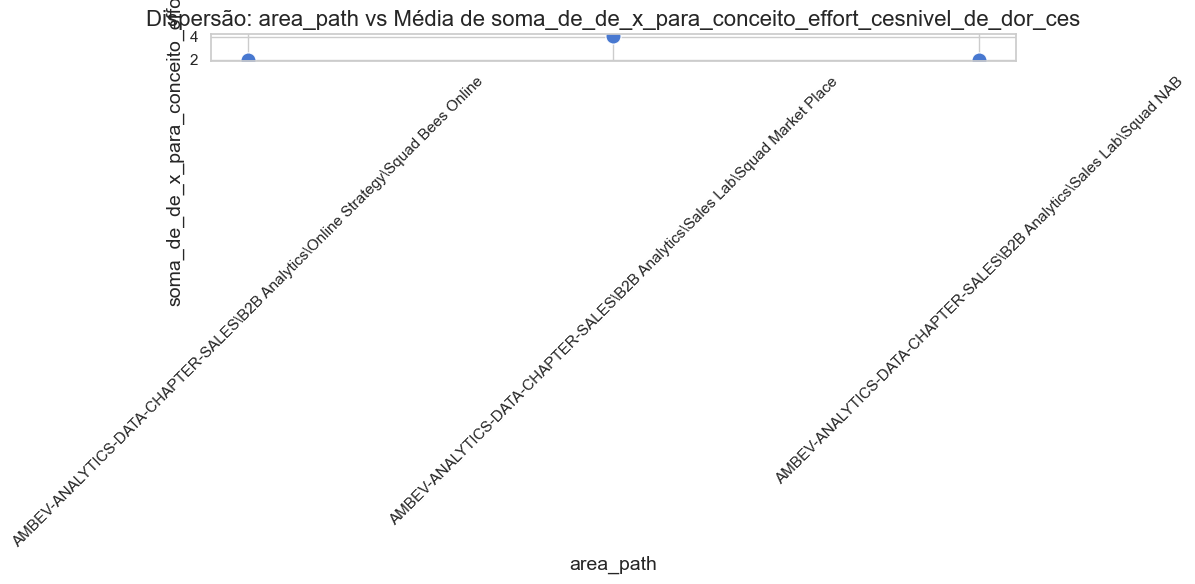

In [17]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=media_col7_por_col1, x=col1, y=col7, s=120)
plt.title(f"Dispersão: {col1} vs Média de {col7}")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [18]:
col12 = df.columns[11]

media_col7_por_col12 = df.groupby(col12)[col7].mean().reset_index()
media_col7_por_col12

,de_x_para_sprintpara,soma_de_de_x_para_conceito_effort_cesnivel_de_dor_ces
0,Backlog,3.969152
1,Q2.24 - S2,2.000000
2,Q2.24 - S5,4.500000
3,Q2.24 - S6,3.899654
4,Q3.24 - S1,4.236842
5,Q3.24 - S2,4.160377
6,Q3.24 - S3,3.785714
7,Q3.24 - S4,4.316940
8,Q3.24 - S5,4.284133
9,Q3.24 - S6,3.950980


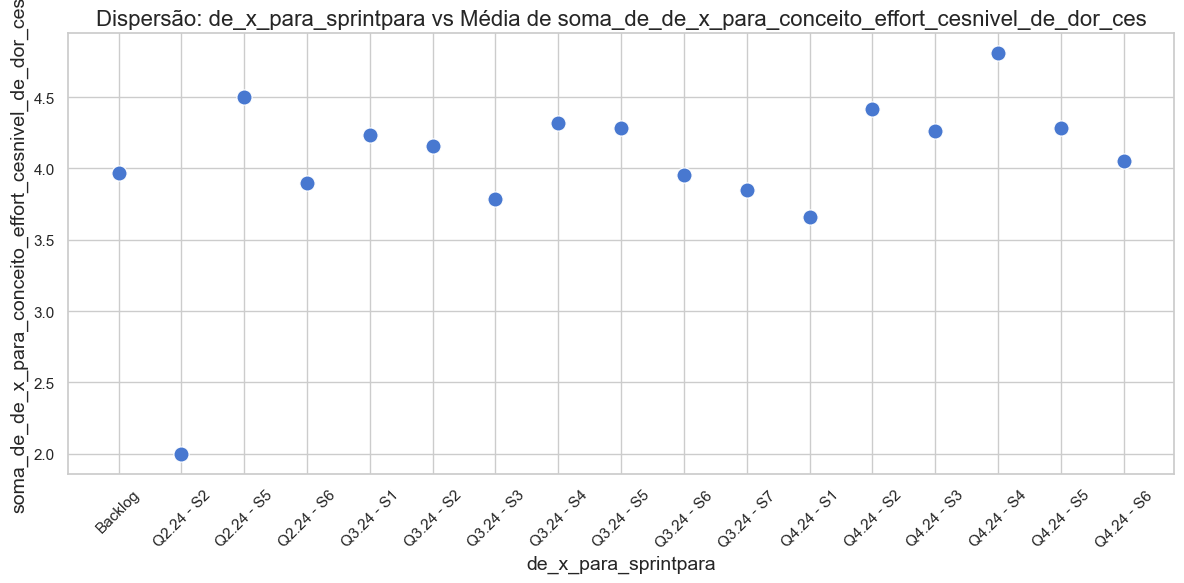

In [19]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=media_col7_por_col12, x=col12, y=col7, s=120)
plt.title(f"Dispersão: {col12} vs Média de {col7}")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
col8 = df.columns[7]

pareto8 = df[col8].value_counts().reset_index()
pareto8.columns = [col8, "quantidade"]
pareto8

,de_x_para_conceito_effort_cesqual_e_a_travanca,quantidade
0,Discovery MIX travado,798
1,Discovery,648
2,Complexidade das métricas,311
3,Diversas ondas de validação,311
4,Modelagem cruzada (contexto de filtro composto),311
5,Acesso ao APP awnsers nielsen,161
6,Velloso vai tentar descobrir se teve novos upg...,161
7,DEV temporário (DEV Vitória infelizmente vai s...,91
8,Discovery sem Mockup,90
9,Diversificação de fatos,90


C:\Users\jesse\AppData\Local\Temp\ipykernel_27296\165366439.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)


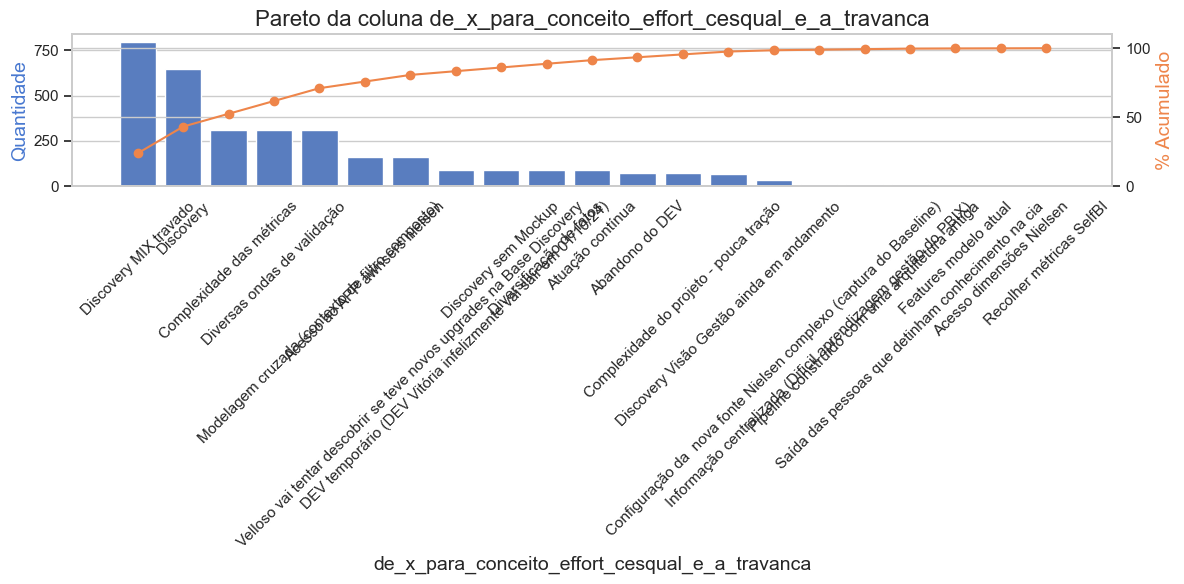

In [21]:
df_pareto = pareto8.copy()
df_pareto["acumulado"] = df_pareto["quantidade"].cumsum()
df_pareto["acumulado_pct"] = df_pareto["acumulado"] / df_pareto["quantidade"].sum() * 100

fig, ax1 = plt.subplots(figsize=(12,6))

sns.barplot(data=df_pareto, x=col8, y="quantidade", ax=ax1, color="C0")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)
ax1.set_ylabel("Quantidade", color="C0")

ax2 = ax1.twinx()
ax2.plot(df_pareto[col8], df_pareto["acumulado_pct"], color="C1", marker="o")
ax2.set_ylabel("% Acumulado", color="C1")
ax2.set_ylim(0, 110)

plt.title(f"Pareto da coluna {col8}")
plt.tight_layout()
plt.show()

In [22]:
col19 = df.columns[18]

pareto19 = df[col19].value_counts().reset_index()
pareto19.columns = [col19, "quantidade"]
pareto19

,work_item_type,quantidade
0,Task,1551
1,Technical Story,679
2,Action,614
3,Business Story,490
4,Analysis Activity,208
5,Bug,37
6,Test Case,24
7,Épico,14


C:\Users\jesse\AppData\Local\Temp\ipykernel_27296\1089001811.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)


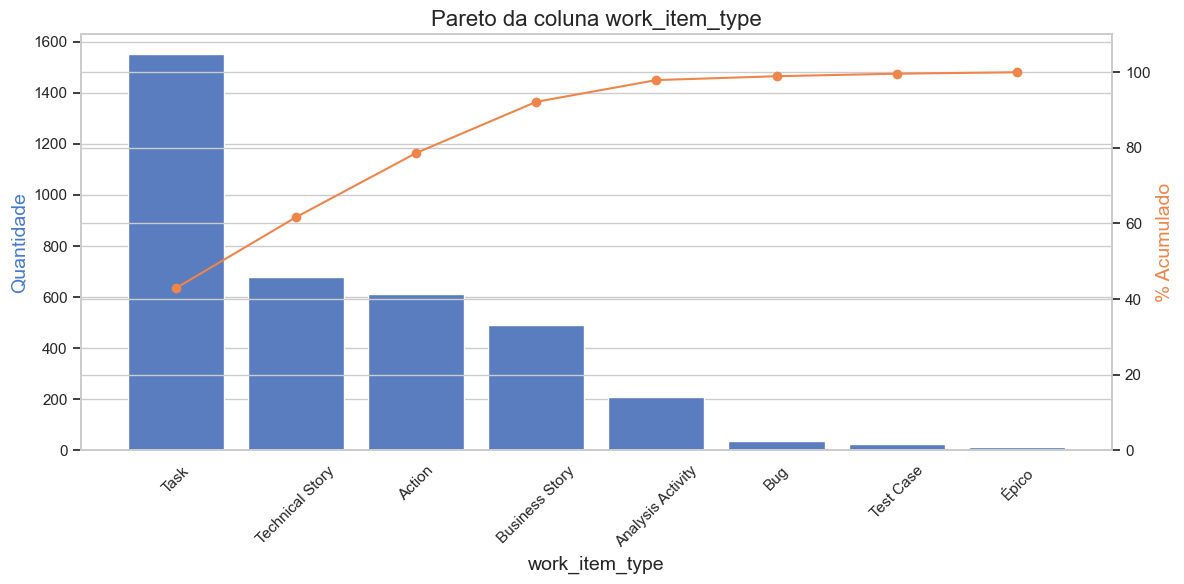

In [23]:
df_pareto19 = pareto19.copy()
df_pareto19["acumulado"] = df_pareto19["quantidade"].cumsum()
df_pareto19["acumulado_pct"] = df_pareto19["acumulado"] / df_pareto19["quantidade"].sum() * 100

fig, ax1 = plt.subplots(figsize=(12,6))

sns.barplot(data=df_pareto19, x=col19, y="quantidade", ax=ax1, color="C0")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)
ax1.set_ylabel("Quantidade", color="C0")

ax2 = ax1.twinx()
ax2.plot(df_pareto19[col19], df_pareto19["acumulado_pct"], color="C1", marker="o")
ax2.set_ylabel("% Acumulado", color="C1")
ax2.set_ylim(0, 110)

plt.title(f"Pareto da coluna {col19}")
plt.tight_layout()
plt.show()

In [25]:
col13 = df.columns[12]

df[["id", "status"]] = df[col13].str.split("_", expand=True)

df[["id", "status"]].head()

,id,status
0,1710313,New
1,1710313,New
2,1710313,New
3,1717048,Waiting-Business-Review
4,1717032,Developing


In [26]:
df[["id", "status"]] = df[col13].str.split("_", n=1, expand=True)

In [27]:
df.head()

,area_path,assigned_to,ano,trimestre,ms,dia,soma_de_de_x_para_conceito_effort_cesnivel_de_dor_ces,de_x_para_conceito_effort_cesqual_e_a_travanca,de_x_para_conceito_effort_cestipo_de_trava,de_x_para_op_versus_epicosolucao,...,idstatus,is_current,iteration_path,state,title,contagem_de_work_item_id,work_item_type,data,id,status
0,AMBEV-ANALYTICS-DATA-CHAPTER-SALES\B2B Analyti...,Matheus de Oliveira Trindade,2024,Trim 4,outubro,31,2.0,Discovery MIX travado,Mapeamento,BI Farol TTV 3.0,...,1710313_New,False,AMBEV-ANALYTICS-DATA-CHAPTER-SALES\Digital Ins...,New,Input Manual - DeParaSKU e MkupRedes,1,Action,NaT,1710313,New
1,AMBEV-ANALYTICS-DATA-CHAPTER-SALES\B2B Analyti...,Matheus de Oliveira Trindade,2024,Trim 4,novembro,30,2.0,Discovery MIX travado,Mapeamento,BI Farol TTV 3.0,...,1710313_New,False,AMBEV-ANALYTICS-DATA-CHAPTER-SALES\Digital Ins...,New,Input Manual - DeParaSKU e MkupRedes,1,Action,NaT,1710313,New
2,AMBEV-ANALYTICS-DATA-CHAPTER-SALES\B2B Analyti...,Matheus de Oliveira Trindade,2024,Trim 4,dezembro,20,2.0,Discovery MIX travado,Mapeamento,BI Farol TTV 3.0,...,1710313_New,True,AMBEV-ANALYTICS-DATA-CHAPTER-SALES\Digital Ins...,New,Input Manual - DeParaSKU e MkupRedes,1,Action,NaT,1710313,New
3,AMBEV-ANALYTICS-DATA-CHAPTER-SALES\B2B Analyti...,Adalton Neto,2024,Trim 4,outubro,31,NaN,NaN,NaN,Demanda Squad,...,1717048_Waiting-Business-Review,False,AMBEV-ANALYTICS-DATA-CHAPTER-SALES\Digital Ins...,Waiting-Business-Review,Suporte PRICE INDEX,1,Technical Story,NaT,1717048,Waiting-Business-Review
4,AMBEV-ANALYTICS-DATA-CHAPTER-SALES\B2B Analyti...,Adalton Neto,2024,Trim 4,outubro,31,NaN,NaN,NaN,Price Index,...,1717032_Developing,False,AMBEV-ANALYTICS-DATA-CHAPTER-SALES\Digital Ins...,Developing,Apresentação ao Stakeholder,1,Business Story,NaT,1717032,Developing


In [28]:
# Pareto da coluna Status

pareto_status = df["status"].value_counts().reset_index()
pareto_status.columns = ["status", "quantidade"]
pareto_status

,status,quantidade
0,Done,2928
1,To Do,171
2,Canceled,125
3,New,105
4,Developing,72
5,In-Refinement,70
6,Waiting-Development,66
7,In-Business-Review,32
8,Ready,12
9,Closed,12


C:\Users\jesse\AppData\Local\Temp\ipykernel_27296\1653001686.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)


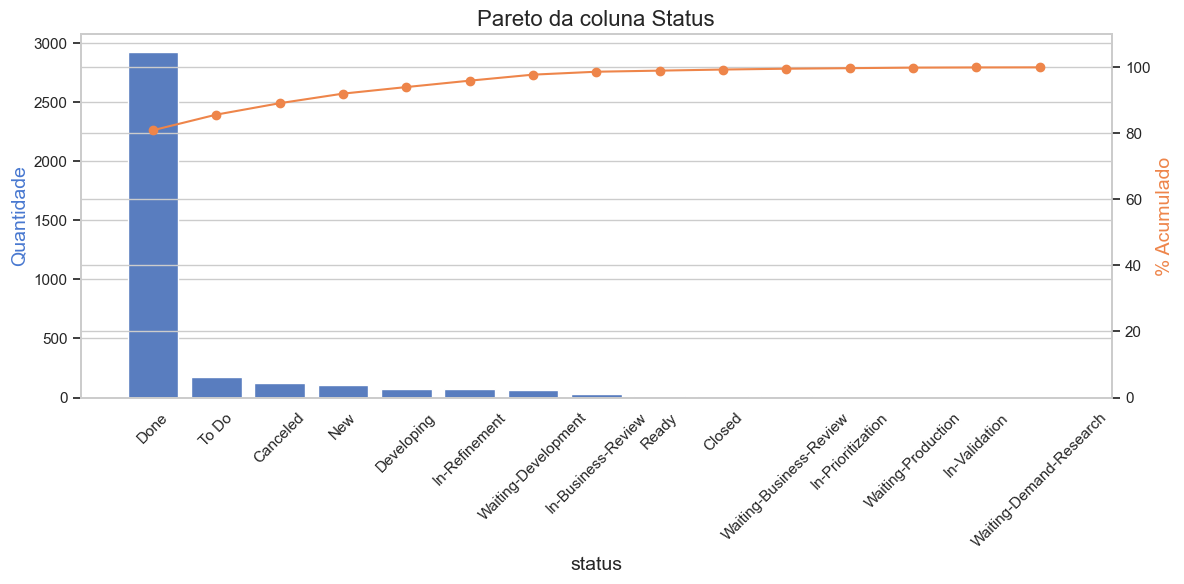

In [29]:
df_pareto_status = pareto_status.copy()
df_pareto_status["acumulado"] = df_pareto_status["quantidade"].cumsum()
df_pareto_status["acumulado_pct"] = (
    df_pareto_status["acumulado"] / df_pareto_status["quantidade"].sum() * 100
)

fig, ax1 = plt.subplots(figsize=(12,6))

# Barras
sns.barplot(
    data=df_pareto_status,
    x="status",
    y="quantidade",
    ax=ax1,
    color="C0"
)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)
ax1.set_ylabel("Quantidade", color="C0")

# Linha acumulada
ax2 = ax1.twinx()
ax2.plot(
    df_pareto_status["status"],
    df_pareto_status["acumulado_pct"],
    color="C1",
    marker="o"
)
ax2.set_ylabel("% Acumulado", color="C1")
ax2.set_ylim(0, 110)

plt.title("Pareto da coluna Status")
plt.tight_layout()
plt.show()